Input shape: torch.Size([2, 32, 32])
Label: 0.0


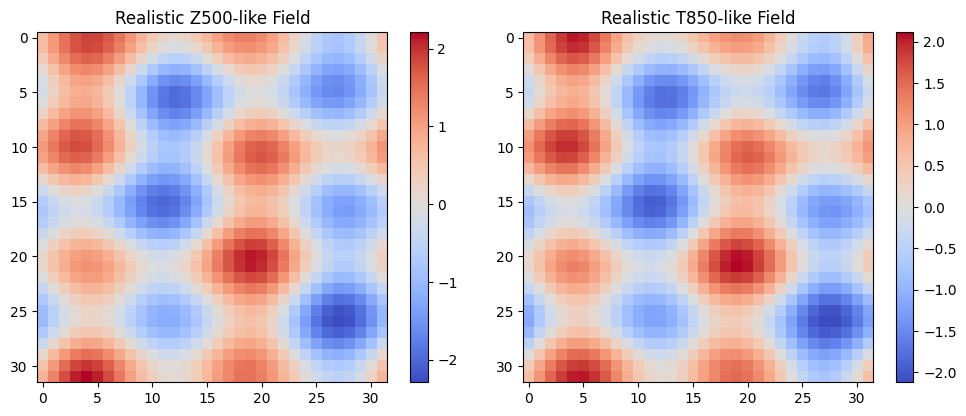

Epoch 1 | Loss 0.0621
Epoch 2 | Loss 0.0000
Epoch 3 | Loss 0.0000
Epoch 4 | Loss 0.0000
Epoch 5 | Loss 0.0000
Epoch 6 | Loss 0.0000
Epoch 7 | Loss 0.0000
Epoch 8 | Loss 0.0000


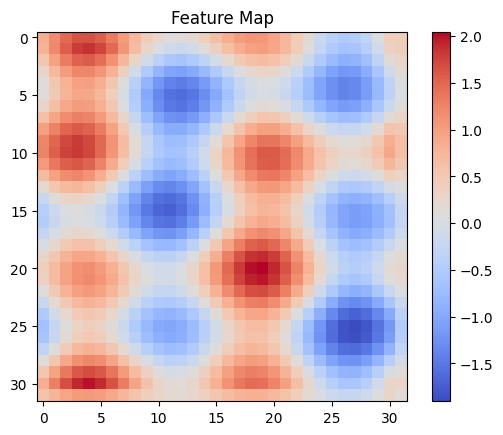

In [2]:
# ============================================================
# CNN Prototype — Realistic Atmospheric Inputs
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


# ============================================================
# Helper: Create Realistic Atmospheric Field
# ============================================================

def generate_wave_field(grid_size):

    x = np.linspace(0, 2*np.pi, grid_size)
    y = np.linspace(0, 2*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)

    # Rossby-like waves
    field = (
        np.sin(2*X) +
        0.7*np.cos(3*Y) +
        0.5*np.sin(X+Y)
    )

    # Add smooth noise
    noise = gaussian_filter(np.random.randn(grid_size,grid_size), sigma=2)
    field += 0.5 * noise

    return field


# ============================================================
# Dataset
# ============================================================

class RealisticWeatherDataset(Dataset):

    def __init__(self, n_samples=2000, grid_size=32):

        self.X = np.zeros((n_samples,2,grid_size,grid_size))
        self.y = np.zeros(n_samples)

        cx, cy = grid_size//2, grid_size//2

        for i in range(n_samples):

            z500 = generate_wave_field(grid_size)
            t850 = generate_wave_field(grid_size)

            # Inject realistic heatwave structure
            if np.random.rand() < 0.3:
                blob = gaussian_filter(np.ones((12,12)), sigma=3)

                z500[cx-6:cx+6, cy-6:cy+6] += blob * 2.5
                t850[cx-6:cx+6, cy-6:cy+6] += blob * 2.0
                self.y[i] = 1

            self.X[i,0] = z500
            self.X[i,1] = t850

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.float32),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )


# ============================================================
# CNN Model (unchanged)
# ============================================================

class HeatwaveCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(2,16,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*8*8,64),
            nn.ReLU(),
            nn.Linear(64,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        x = self.features(x)
        return self.classifier(x).squeeze()


# ============================================================
# Create Dataset
# ============================================================

dataset = RealisticWeatherDataset()
loader = DataLoader(dataset, batch_size=32, shuffle=True)

sample_X, sample_y = dataset[0]

print("Input shape:", sample_X.shape)
print("Label:", sample_y.item())


# ============================================================
# Display Realistic Input
# ============================================================

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_X[0], cmap="coolwarm")
plt.title("Realistic Z500-like Field")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(sample_X[1], cmap="coolwarm")
plt.title("Realistic T850-like Field")
plt.colorbar()

plt.tight_layout()
plt.show()


# ============================================================
# Train CNN
# ============================================================

model = HeatwaveCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

for epoch in range(8):

    total_loss = 0
    for X,y in loader:
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred,y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss {total_loss/len(loader):.4f}")


# ============================================================
# Feature Map Visualization
# ============================================================

with torch.no_grad():
    fmap = model.features[0](sample_X.unsqueeze(0))

plt.imshow(fmap[0,0].numpy(), cmap="coolwarm")
plt.title("Feature Map")
plt.colorbar()
plt.show()